# 03 - Evaluation & Visualization
This notebook evaluates the trained LSTM model and visualizes RUL predictions for multiple components.

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sys
import os
sys.path.append(os.path.abspath("../src"))
from model_architectures import LSTMRegressor

In [10]:
# Load validation/test data
X = np.load('../outputs/X.npy')
y = np.load('../outputs/y.npy')
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_ds, batch_size=64)

In [11]:
# Load trained model
model = LSTMRegressor(input_dim=X.shape[2], hidden_dim=64, num_layers=2, output_dim=y.shape[1])
model.load_state_dict(torch.load('../models/multi_rul_lstm.pt'))
model.eval()

LSTMRegressor(
  (lstm): LSTM(21, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

In [ ]:
# Predict and evaluate
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        all_preds.append(preds.numpy())
        all_targets.append(yb.numpy())

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_targets)

# Print metrics per component
for i, comp in enumerate(['comp1', 'comp2', 'comp3']):
    mse = mean_squared_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    print(f"{comp} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

comp1 - RMSE: 82.06, MAE: 65.99
comp2 - RMSE: 82.06, MAE: 65.99
comp3 - RMSE: 82.06, MAE: 65.99


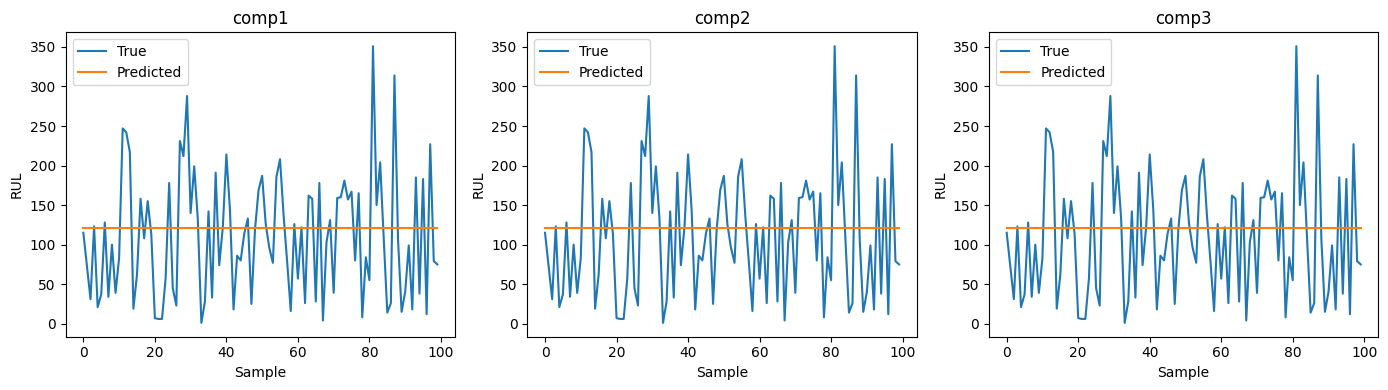

In [17]:
# Plot true vs predicted RUL (sample of 100)
num_plot = 100
plt.figure(figsize=(14, 4))
for i, comp in enumerate(['comp1', 'comp2', 'comp3']):
    plt.subplot(1, 3, i+1)
    plt.plot(y_true[:num_plot, i], label='True')
    plt.plot(y_pred[:num_plot, i], label='Predicted')
    plt.title(comp)
    plt.xlabel('Sample')
    plt.ylabel('RUL')
    plt.legend()
plt.tight_layout()
plt.show()